# **Question 1**
Fragment length frequency (1 mark) + rescaling (2 marks) You are given a file (see link below) with each line indicating where a DNA fragment has mapped on the chromosome. Your goal is to count individual fragment lengths, and then normalize it by the total count of all fragment lengths. Once you have the normalized count, you will plot that using plotting packages in Python. X-axis will be fragment length (unit: base pairs) and Y-axis will be labelled "Narmalized Frequency [A.U.]". Fragment length can simply be calculated by subtracting 2nd column from the 3rd.

query.bed.gz

Rescaling Often, you will received two sets of data with differnt emperical distribution. The goal is to rescale one (query) to the other (reference). In this part, you will write codes to achieve this. You are given a reference distribution (reference.hist) and a query bed file (query.bed.gz). You have to rescale (subsample the data) so that when you draw the normalized frequency, it should almost match the reference.

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


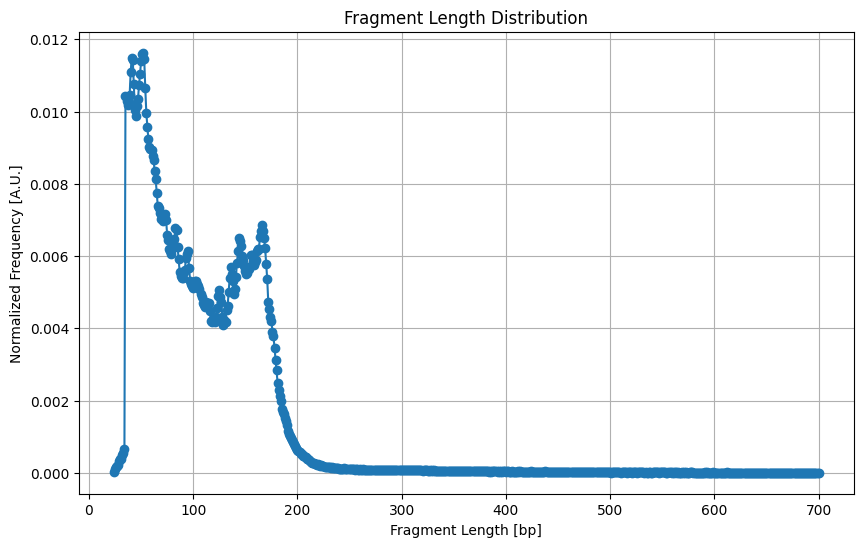

In [3]:
import gzip
import matplotlib.pyplot as plt
from collections import Counter

#  Read the .bed.gz file and calculate fragment lengths
fragment_lengths = []

#  add the filepath accordingly
file_path = '/content/drive/MyDrive/query.bed.gz'
with gzip.open(file_path, 'rt') as f:
    for line in f:
        if line.strip() == '':
            continue
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            start = int(parts[1])
            end = int(parts[2])
            fragment_length = end - start
            if fragment_length > 0:
                fragment_lengths.append(fragment_length)

#  Counting fragment lengths
length_counter = Counter(fragment_lengths)

# Normalizing the counts
total_fragments = sum(length_counter.values())
normalized_freq = {length: count / total_fragments for length, count in length_counter.items()}

# ploting
x = sorted(normalized_freq.keys())
y = [normalized_freq[length] for length in x]

plt.figure(figsize=(10,6))
plt.plot(x, y, marker='o', linestyle='-')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.title('Fragment Length Distribution')
plt.grid(True)
plt.show()


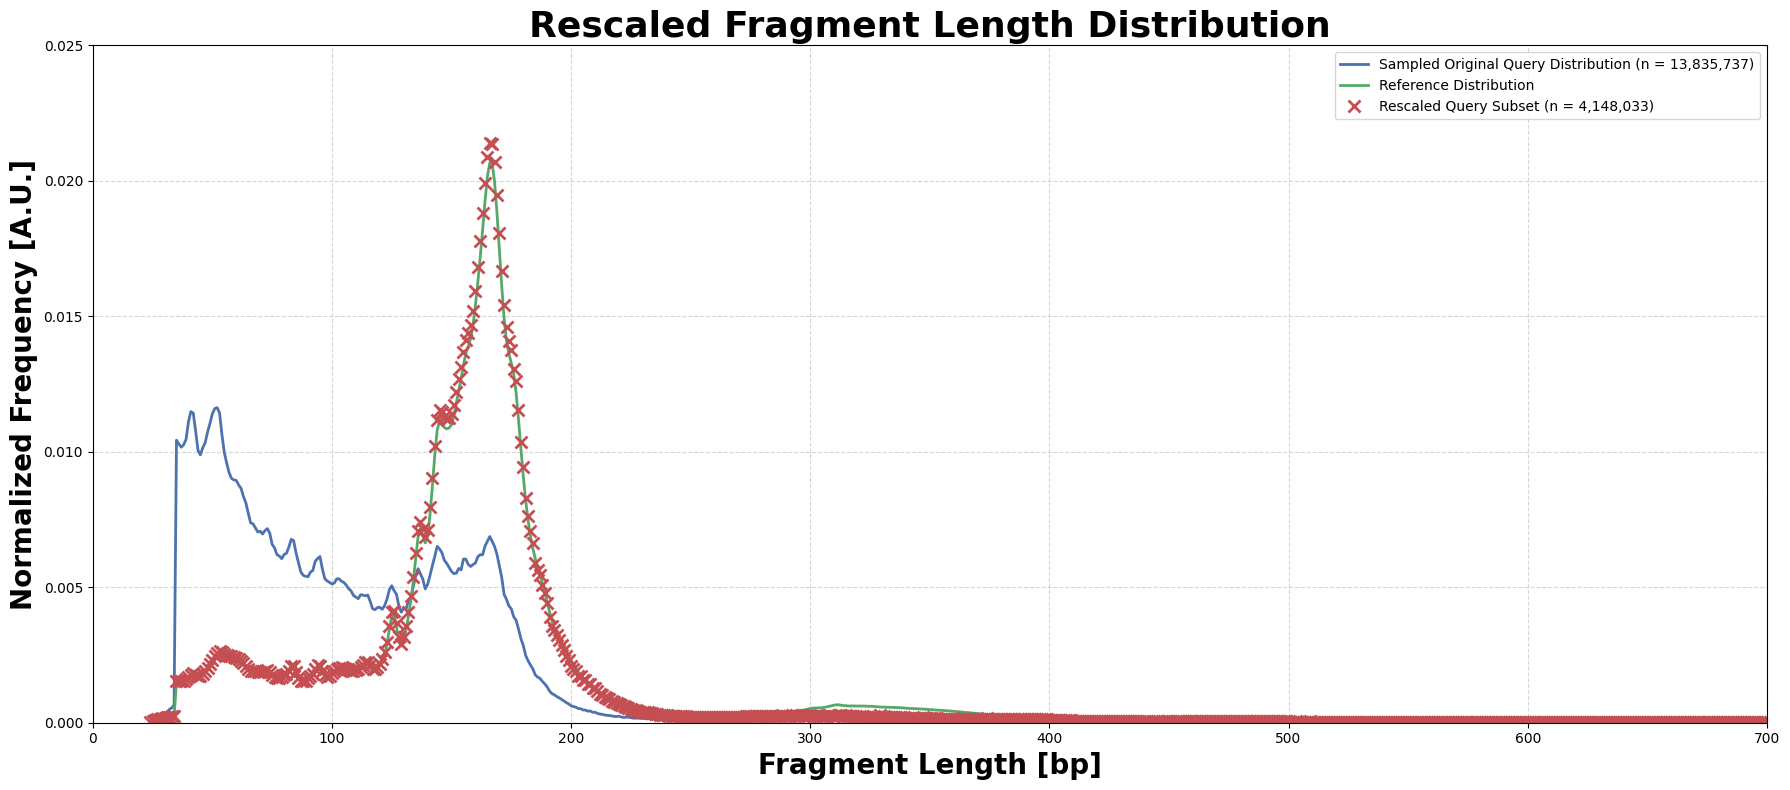

In [4]:
import gzip
import matplotlib.pyplot as plt
from collections import Counter
import random


def load_reference_hist(path):
    with open(path) as f:
        ref = {int(l): float(f) for l, f in (line.strip().split('\t') for line in f if line.strip())}
    total = sum(ref.values())
    return {k: v / total for k, v in ref.items()}

ref_freq_dict = load_reference_hist('/content/drive/MyDrive/reference.hist')

# --- Load fragment lengths from query.bed.gz ---
def load_fragment_lengths(bed_path):
    with gzip.open(bed_path, 'rt') as f:
        return [int(p[2]) - int(p[1]) for p in (line.strip().split('\t') for line in f if line.strip()) if int(p[2]) > int(p[1])]

fragment_lengths = load_fragment_lengths('/content/drive/MyDrive/query.bed.gz')
length_freq = Counter(fragment_lengths)
total_fragments = sum(length_freq.values())

# --- Normalize query frequency ---
normalized_query_freq = {l: c / total_fragments for l, c in length_freq.items()}
sorted_lengths = sorted(normalized_query_freq.keys())
sorted_freqs = [normalized_query_freq[l] for l in sorted_lengths]

# --- Subsample (rescale) query to match reference ---
frag_by_length = {}
for l in fragment_lengths:
    frag_by_length.setdefault(l, []).append(l)

# Set the desired total counts
original_query_count = 13835737
rescaled_query_count = 4295020

rescaled_fragments = []

# Rescale to match the reference distribution
for l, ref_freq in ref_freq_dict.items():
    if l in frag_by_length:
        desired_count = int(ref_freq * rescaled_query_count)
        pool = frag_by_length[l]
        sampled = random.sample(pool, min(len(pool), desired_count))
        rescaled_fragments.extend(sampled)

# --- Compute rescaled frequency ---
rescaled_counts = Counter(rescaled_fragments)
total_rescaled = sum(rescaled_counts.values())
rescaled_freq = {l: c / total_rescaled for l, c in rescaled_counts.items()}

# --- Prepare reference data for plotting ---
ref_lengths = sorted(ref_freq_dict.keys())
ref_freqs = [ref_freq_dict[l] for l in ref_lengths]

# --- Plot with improved styling ---
plt.figure(figsize=(18, 8))

# Custom font settings
font_title = {'fontsize': 26, 'weight': 'bold'}
font_labels = {'fontsize': 20, 'weight': 'semibold'}
font_legend = {'fontsize': 14}

# Sample the original query to exactly 13,835,737 fragments
sampled_fragments = random.sample(fragment_lengths, original_query_count)
length_freq_sampled = Counter(sampled_fragments)
normalized_query_freq_sampled = {l: c / sum(length_freq_sampled.values()) for l, c in length_freq_sampled.items()}
sorted_sampled_lengths = sorted(normalized_query_freq_sampled.keys())
sorted_sampled_freqs = [normalized_query_freq_sampled[l] for l in sorted_sampled_lengths]

plt.plot(sorted_sampled_lengths, sorted_sampled_freqs,
         label=f'Sampled Original Query Distribution (n = {original_query_count:,})',
         color='#4C72B0', linewidth=2)

plt.plot(ref_lengths, ref_freqs,
         label='Reference Distribution',
         color='#55A868', linewidth=2)

plt.plot(sorted(rescaled_freq.keys()),
         [rescaled_freq[l] for l in sorted(rescaled_freq.keys())],
         'x', label=f'Rescaled Query Subset (n = {total_rescaled:,})',
         color='#C44E52', markersize=8, markeredgewidth=2)

plt.xlabel("Fragment Length [bp]", **font_labels)
plt.ylabel("Normalized Frequency [A.U.]", **font_labels)
plt.title("Rescaled Fragment Length Distribution", **font_title)
plt.xlim(0, 700)
plt.ylim(0, 0.025)

# Legend with improved readability
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("./rescaled_prediction.png")
plt.show()
